In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error

In [117]:
# from google.colab import files
# files.upload()

In [146]:
df = pd.read_csv("GOOG.csv")
data = df['close'].values.reshape(-1, 1)

In [147]:
sequence_length = 60
X, y = [], []
for i in range(len(data) - sequence_length):
    X.append(data[i:i + sequence_length])
    y.append(data[i + sequence_length])

X = np.array(X)
y = np.array(y)

In [148]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

In [149]:
num_samples, seq_len, num_features = X.shape
X = X.reshape(-1, 1)
X = scaler_X.fit_transform(X)
X = X.reshape(num_samples, seq_len, num_features)

y = scaler_y.fit_transform(y)


In [150]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [151]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [152]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [153]:
model1 = LSTMModel(input_size=1, hidden_size=50, num_layers=2)
model2 = LSTMModel(input_size=1, hidden_size=100, num_layers=3)
# Loss and Optimizer
criterion = nn.MSELoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

In [154]:
def train_model(model, optimizer, X_train, y_train, epochs=50, batch_size=32):
    dataset = TensorDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []
    maes = []

    for epoch in range(epochs):
        epoch_loss = 0
        epoch_mae = 0
        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_mae += mean_absolute_error(y_batch.detach().numpy(), y_pred.detach().numpy())

        epoch_loss /= len(dataloader)
        epoch_mae /= len(dataloader)
        losses.append(epoch_loss)
        maes.append(epoch_mae)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}, MAE: {epoch_mae:.6f}")

    return losses, maes

print("Training Model 1:")
losses1, maes1 = train_model(model1, optimizer1, X_train, y_train, epochs=50)

print("\nTraining Model 2:")
losses2, maes2 = train_model(model2, optimizer2, X_train, y_train, epochs=50)

Training Model 1:
Epoch 1/50, Loss: 0.013817, MAE: 0.092773
Epoch 2/50, Loss: 0.008039, MAE: 0.071144
Epoch 3/50, Loss: 0.002385, MAE: 0.038516
Epoch 4/50, Loss: 0.001044, MAE: 0.025252
Epoch 5/50, Loss: 0.000604, MAE: 0.018053
Epoch 6/50, Loss: 0.000538, MAE: 0.016961
Epoch 7/50, Loss: 0.000470, MAE: 0.015715
Epoch 8/50, Loss: 0.000455, MAE: 0.015580
Epoch 9/50, Loss: 0.000438, MAE: 0.015311
Epoch 10/50, Loss: 0.000393, MAE: 0.014262
Epoch 11/50, Loss: 0.000404, MAE: 0.014581
Epoch 12/50, Loss: 0.000380, MAE: 0.014124
Epoch 13/50, Loss: 0.000394, MAE: 0.014684
Epoch 14/50, Loss: 0.000350, MAE: 0.013420
Epoch 15/50, Loss: 0.000362, MAE: 0.014075
Epoch 16/50, Loss: 0.000337, MAE: 0.013498
Epoch 17/50, Loss: 0.000319, MAE: 0.013090
Epoch 18/50, Loss: 0.000330, MAE: 0.013465
Epoch 19/50, Loss: 0.000301, MAE: 0.012620
Epoch 20/50, Loss: 0.000314, MAE: 0.012925
Epoch 21/50, Loss: 0.000292, MAE: 0.012535
Epoch 22/50, Loss: 0.000297, MAE: 0.012936
Epoch 23/50, Loss: 0.000301, MAE: 0.012941
Ep

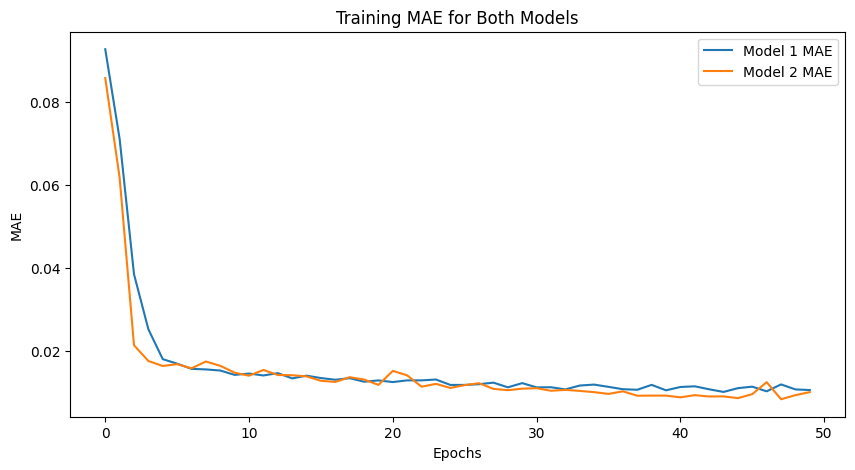

In [155]:
plt.figure(figsize=(10,5))
plt.plot(maes1, label='Model 1 MAE')
plt.plot(maes2, label='Model 2 MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training MAE for Both Models')
plt.legend()
plt.show()

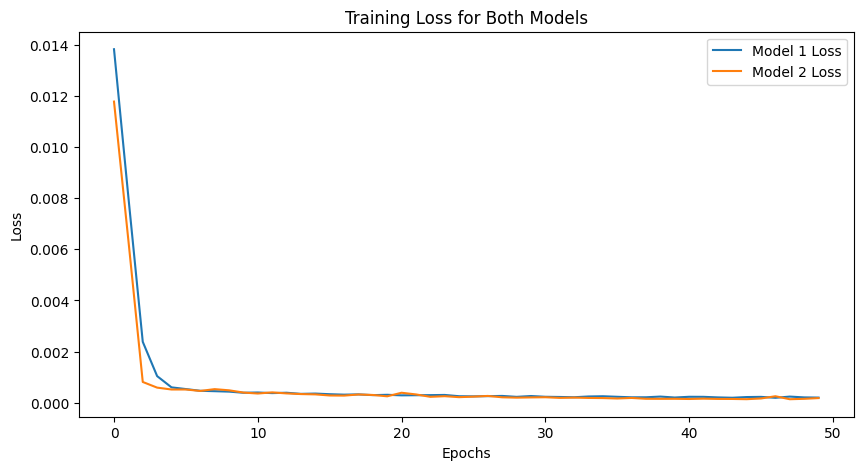

In [156]:
plt.figure(figsize=(10,5))
plt.plot(losses1, label='Model 1 Loss')
plt.plot(losses2, label='Model 2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss for Both Models')
plt.legend()
plt.show()

In [157]:
def predict(model, X):
    with torch.no_grad():
        return model(X).numpy()

y_pred1 = predict(model1, X_test)
y_pred2 = predict(model2, X_test)

In [158]:
y_test_actual = scaler_y.inverse_transform(y_test.numpy())
y_pred1_actual = scaler_y.inverse_transform(y_pred1)
y_pred2_actual = scaler_y.inverse_transform(y_pred2)

In [159]:
mse1 = np.mean((y_test_actual - y_pred1_actual) ** 2)
mse2 = np.mean((y_test_actual - y_pred2_actual) ** 2)

print(f"Model 1 MSE: {mse1}")
print(f"Model 2 MSE: {mse2}")

Model 1 MSE: 2599.61083984375
Model 2 MSE: 1698.6846923828125


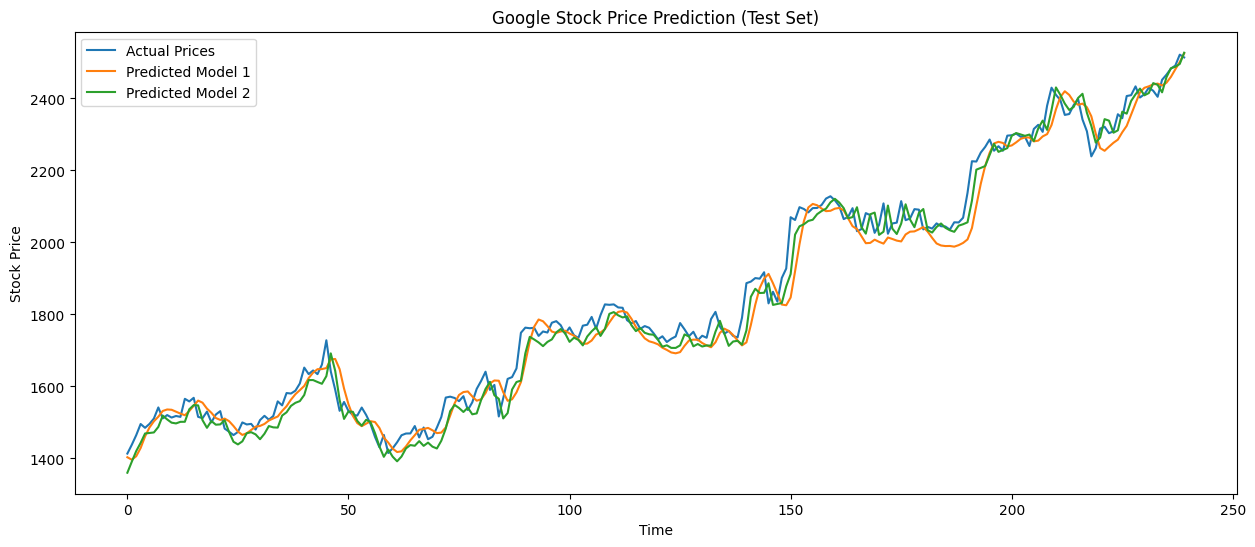

In [160]:
plt.figure(figsize=(15,6))
plt.plot(y_test_actual, label='Actual Prices')
plt.plot(y_pred1_actual, label='Predicted Model 1')
plt.plot(y_pred2_actual, label='Predicted Model 2')
plt.legend()
plt.title('Google Stock Price Prediction (Test Set)')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.show()